# Background Illumination Removal — Benchmark

Compares background correction strategies on the CT/tomography H5 volume before structure-tensor analysis.  
Typical artefacts in micro-CT: **beam-hardening (cupping)**, **scatter**, **ring artefacts**.

| Method | Model | Notes |
|---|---|---|
| Gaussian subtraction | Additive | Fast separable; good for smooth gradients |
| Divide-by-blur | Multiplicative | Flat-field / homomorphic correction |
| Box-filter subtraction | Additive | Faster than Gaussian, same idea |
| Polynomial fit per slice | Additive | 2-D poly per Z-slice; ideal for cupping |
| FFT high-pass | Additive | Removes long-wavelength components in one step |
| White top-hat 2-D per slice | Morphological | Preserves bright compact structures |

**Quality metrics (no ground truth required)**
- *Corner std* — std of corner patches (background proxy; lower = more uniform BG)
- *Gradient sharpness* — mean |∇| (higher = edges preserved)
- *Contrast* — P99 − P1 of corrected slice
- *Runtime* — wall-clock on the 3-D slab

In [1]:
from __future__ import annotations
from pathlib import Path
import time
from typing import Callable, Dict

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, uniform_filter, white_tophat

from structure_tensor.pre_processing import normalize

In [2]:
# ── file ──────────────────────────────────────────────────────────────────────
FILE_PATH = Path(
    "../data/BIIAX_196(245)_02/BIIAX_196(245)_02_2026-04-17_103446"
    "/tomo-A/BIIAX_196(245)_02_tomo-A_recon_crop.h5"
)

# ── scan geometry ─────────────────────────────────────────────────────────────
VOXEL_SIZE_MM = 0.00230760   # mm / px
FIBER_DIAM_MM = 7e-3         # mm
FIBER_R_PX    = FIBER_DIAM_MM / 2 / VOXEL_SIZE_MM  # ≈ 1.5 px

# ── benchmark slab ────────────────────────────────────────────────────────────
SLAB_N = 256   # Z-slices loaded for 3-D benchmark

print(f"Fiber radius ≈ {FIBER_R_PX:.2f} px")

Fiber radius ≈ 1.52 px


## 1  Load & inspect

In [3]:
# Auto-detect 3-D dataset key
vol_key: str | None = None

with h5py.File(FILE_PATH, "r") as f:
    print("Top-level keys:", list(f.keys()))
    for k in f.keys():
        obj = f[k]
        if isinstance(obj, h5py.Dataset):
            print(f"  {k}: shape={obj.shape}  dtype={obj.dtype}")
            if obj.ndim == 3 and vol_key is None:
                vol_key = k

print(f"\nUsing key: '{vol_key}'")

Top-level keys: ['metadata', 'volume']
  volume: shape=(2006, 1383, 1383)  dtype=uint16

Using key: 'volume'


In [4]:
# Optionally override after inspection
# vol_key = "vol_"

with h5py.File(FILE_PATH, "r") as f:
    ds = f[vol_key]
    Z, Y, X = ds.shape
    z0 = (Z - SLAB_N) // 2
    z1 = z0 + SLAB_N
    slab_raw = ds[z0:z1].astype(np.float32)

print(f"Slab : {slab_raw.shape}")
print(f"Range: [{slab_raw.min():.0f}, {slab_raw.max():.0f}]  mean={slab_raw.mean():.0f}")

# Representative 2-D slice used throughout
slice2d = slab_raw[SLAB_N // 2]

Slab : (256, 1383, 1383)
Range: [0, 65535]  mean=16294


## 2  Visualise raw data — detect background non-uniformity

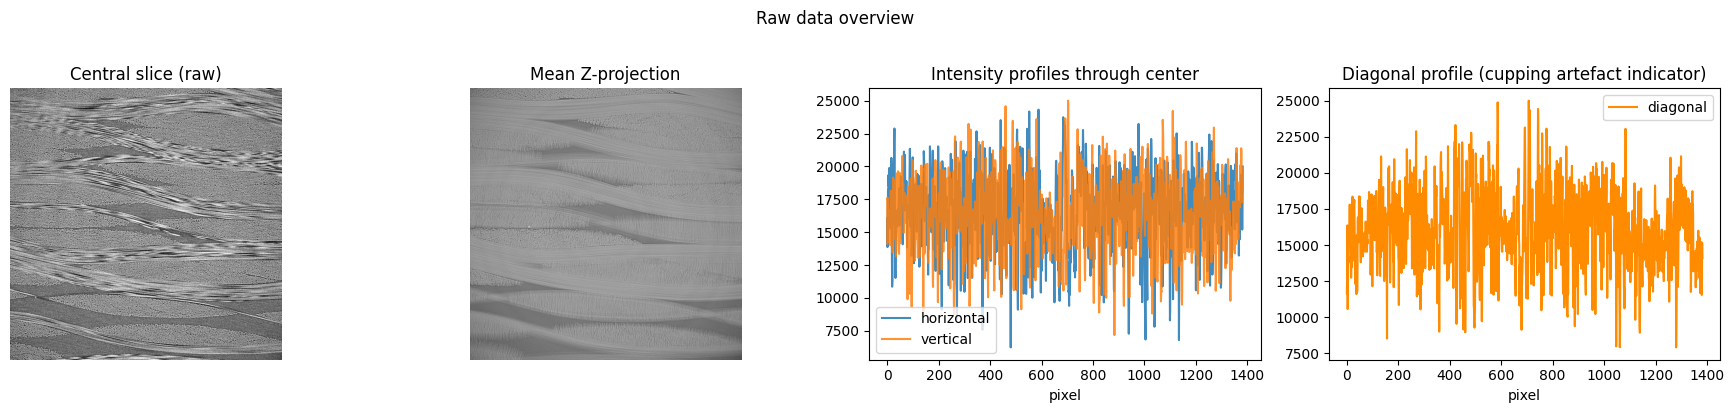

In [5]:
vlo, vhi = np.percentile(slice2d, [1, 99])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(slice2d, cmap="gray", vmin=vlo, vmax=vhi)
axes[0].set_title("Central slice (raw)")
axes[0].axis("off")

axes[1].imshow(slab_raw.mean(axis=0), cmap="gray")
axes[1].set_title("Mean Z-projection")
axes[1].axis("off")

mid_r = slice2d.shape[0] // 2
mid_c = slice2d.shape[1] // 2
axes[2].plot(slice2d[mid_r, :], label="horizontal", alpha=0.85)
axes[2].plot(slice2d[:, mid_c], label="vertical",   alpha=0.85)
axes[2].set_title("Intensity profiles through center")
axes[2].set_xlabel("pixel")
axes[2].legend()

# Diagonal profile to show cupping
diag_len = min(slice2d.shape)
diag_idx = np.arange(diag_len)
diag_vals = slice2d[diag_idx, diag_idx]
axes[3].plot(diag_vals, color="darkorange", label="diagonal")
axes[3].set_title("Diagonal profile (cupping artefact indicator)")
axes[3].set_xlabel("pixel")
axes[3].legend()

plt.suptitle("Raw data overview", y=1.02)
plt.tight_layout()
plt.show()

## 3  Background removal — method definitions

In [6]:
def make_disk(radius: float) -> np.ndarray:
    r = int(np.ceil(radius))
    y, x = np.ogrid[-r : r + 1, -r : r + 1]
    return (y**2 + x**2) <= radius**2

def make_ball(radius: float) -> np.ndarray:
    r = int(np.ceil(radius))
    z, y, x = np.ogrid[-r : r + 1, -r : r + 1, -r : r + 1]
    return (z**2 + y**2 + x**2) <= radius**2

In [7]:
def gaussian_sub(vol: np.ndarray, sigma: float) -> np.ndarray:
    """Subtract Gaussian-blurred background (additive model)."""
    return vol - gaussian_filter(vol, sigma=sigma)


def divide_by_blur(vol: np.ndarray, sigma: float, eps: float | None = None) -> np.ndarray:
    """Divide by blurred background (multiplicative / flat-field model)."""
    if eps is None:
        eps = float(np.percentile(vol, 5)) + 1.0
    bg = gaussian_filter(vol, sigma=sigma)
    return vol / np.maximum(bg, eps)


def box_sub(vol: np.ndarray, size: int) -> np.ndarray:
    """Subtract uniform (box) filtered background — faster than Gaussian."""
    return vol - uniform_filter(vol, size=size)


def poly_bg_per_slice(vol: np.ndarray, deg: int = 3) -> np.ndarray:
    """Fit a 2-D polynomial to each Z-slice and subtract."""
    out = np.empty_like(vol)
    H, W = vol.shape[1], vol.shape[2]
    yn, xn = np.mgrid[0:H, 0:W]
    yn = yn / H - 0.5
    xn = xn / W - 0.5

    cols = []
    for i in range(deg + 1):
        for j in range(deg + 1 - i):
            cols.append((xn**i * yn**j).ravel())
    A = np.column_stack(cols).astype(np.float32)  # (H*W, n_terms)

    for zi in range(vol.shape[0]):
        s = vol[zi].ravel()
        coeffs, _, _, _ = np.linalg.lstsq(A, s, rcond=None)
        out[zi] = vol[zi] - (A @ coeffs).reshape(H, W)
    return out


def fft_highpass(vol: np.ndarray, cutoff_fraction: float = 0.03) -> np.ndarray:
    """Zero out spatial frequencies below cutoff_fraction (fraction of Nyquist)."""
    F = np.fft.rfftn(vol)
    fz = np.fft.fftfreq(vol.shape[0])[:, None, None]
    fy = np.fft.fftfreq(vol.shape[1])[None, :, None]
    fx = np.fft.rfftfreq(vol.shape[2])[None, None, :]
    freq_mag = np.sqrt(fz**2 + fy**2 + fx**2)
    F[freq_mag < cutoff_fraction] = 0
    return np.real(np.fft.irfftn(F, s=vol.shape))


def tophat_2d_per_slice(vol: np.ndarray, radius: float) -> np.ndarray:
    """White top-hat (2-D disk) applied slice-by-slice."""
    disk = make_disk(radius)
    out = np.empty_like(vol)
    for zi in range(vol.shape[0]):
        out[zi] = white_tophat(vol[zi], footprint=disk)
    return out


def tophat_3d(vol: np.ndarray, radius: float) -> np.ndarray:
    """White top-hat (3-D ball) — slow for large radius, use carefully."""
    ball = make_ball(radius)
    return white_tophat(vol, footprint=ball)

## 4  2-D benchmark — single representative slice

In [8]:
# Each lambda receives a 3-D array  (1, H, W)
METHODS_2D: Dict[str, Callable] = {
    "gaussian_sub σ=30":    lambda v: gaussian_sub(v, sigma=30),
    "gaussian_sub σ=50":    lambda v: gaussian_sub(v, sigma=50),
    "gaussian_sub σ=100":   lambda v: gaussian_sub(v, sigma=100),
    "divide_blur  σ=50":    lambda v: divide_by_blur(v, sigma=50),
    "box_sub  sz=50":        lambda v: box_sub(v, size=50),
    "box_sub  sz=100":       lambda v: box_sub(v, size=100),
    "poly deg=2":            lambda v: poly_bg_per_slice(v, deg=2),
    "poly deg=4":            lambda v: poly_bg_per_slice(v, deg=4),
    "fft hp=0.02":           lambda v: fft_highpass(v, cutoff_fraction=0.02),
    "fft hp=0.05":           lambda v: fft_highpass(v, cutoff_fraction=0.05),
    "tophat_2d r=10":        lambda v: tophat_2d_per_slice(v, radius=10),
    "tophat_2d r=20":        lambda v: tophat_2d_per_slice(v, radius=20),
}

In [9]:
s3d = slice2d[np.newaxis]  # (1, H, W)

results_2d: Dict[str, dict] = {}
for name, fn in METHODS_2D.items():
    t0 = time.perf_counter()
    out = fn(s3d)
    dt = time.perf_counter() - t0
    results_2d[name] = {"img": out[0], "time_ms": dt * 1000}
    print(f"{name:<24}  {dt*1000:7.1f} ms")

gaussian_sub σ=30           912.8 ms
gaussian_sub σ=50          1690.3 ms
gaussian_sub σ=100         3768.7 ms
divide_blur  σ=50          1633.6 ms
box_sub  sz=50              109.3 ms
box_sub  sz=100             257.5 ms
poly deg=2                  152.8 ms
poly deg=4                  589.5 ms
fft hp=0.02                  99.7 ms
fft hp=0.05                  88.3 ms


/var/folders/gm/2k8yc0ms0_g90874438x0cf80000gn/T/ipykernel_40490/3035423333.py:48: DeprecationWarning: `axes` should not be `None` if `s` is not `None` (Deprecated in NumPy 2.0). In a future version of NumPy, this will raise an error and `s[i]` will correspond to the size along the transformed axis specified by `axes[i]`. To retain current behaviour, pass a sequence [0, ..., k-1] to `axes` for an array of dimension k.
  return np.real(np.fft.irfftn(F, s=vol.shape))


tophat_2d r=10             1306.2 ms
tophat_2d r=20             4524.7 ms


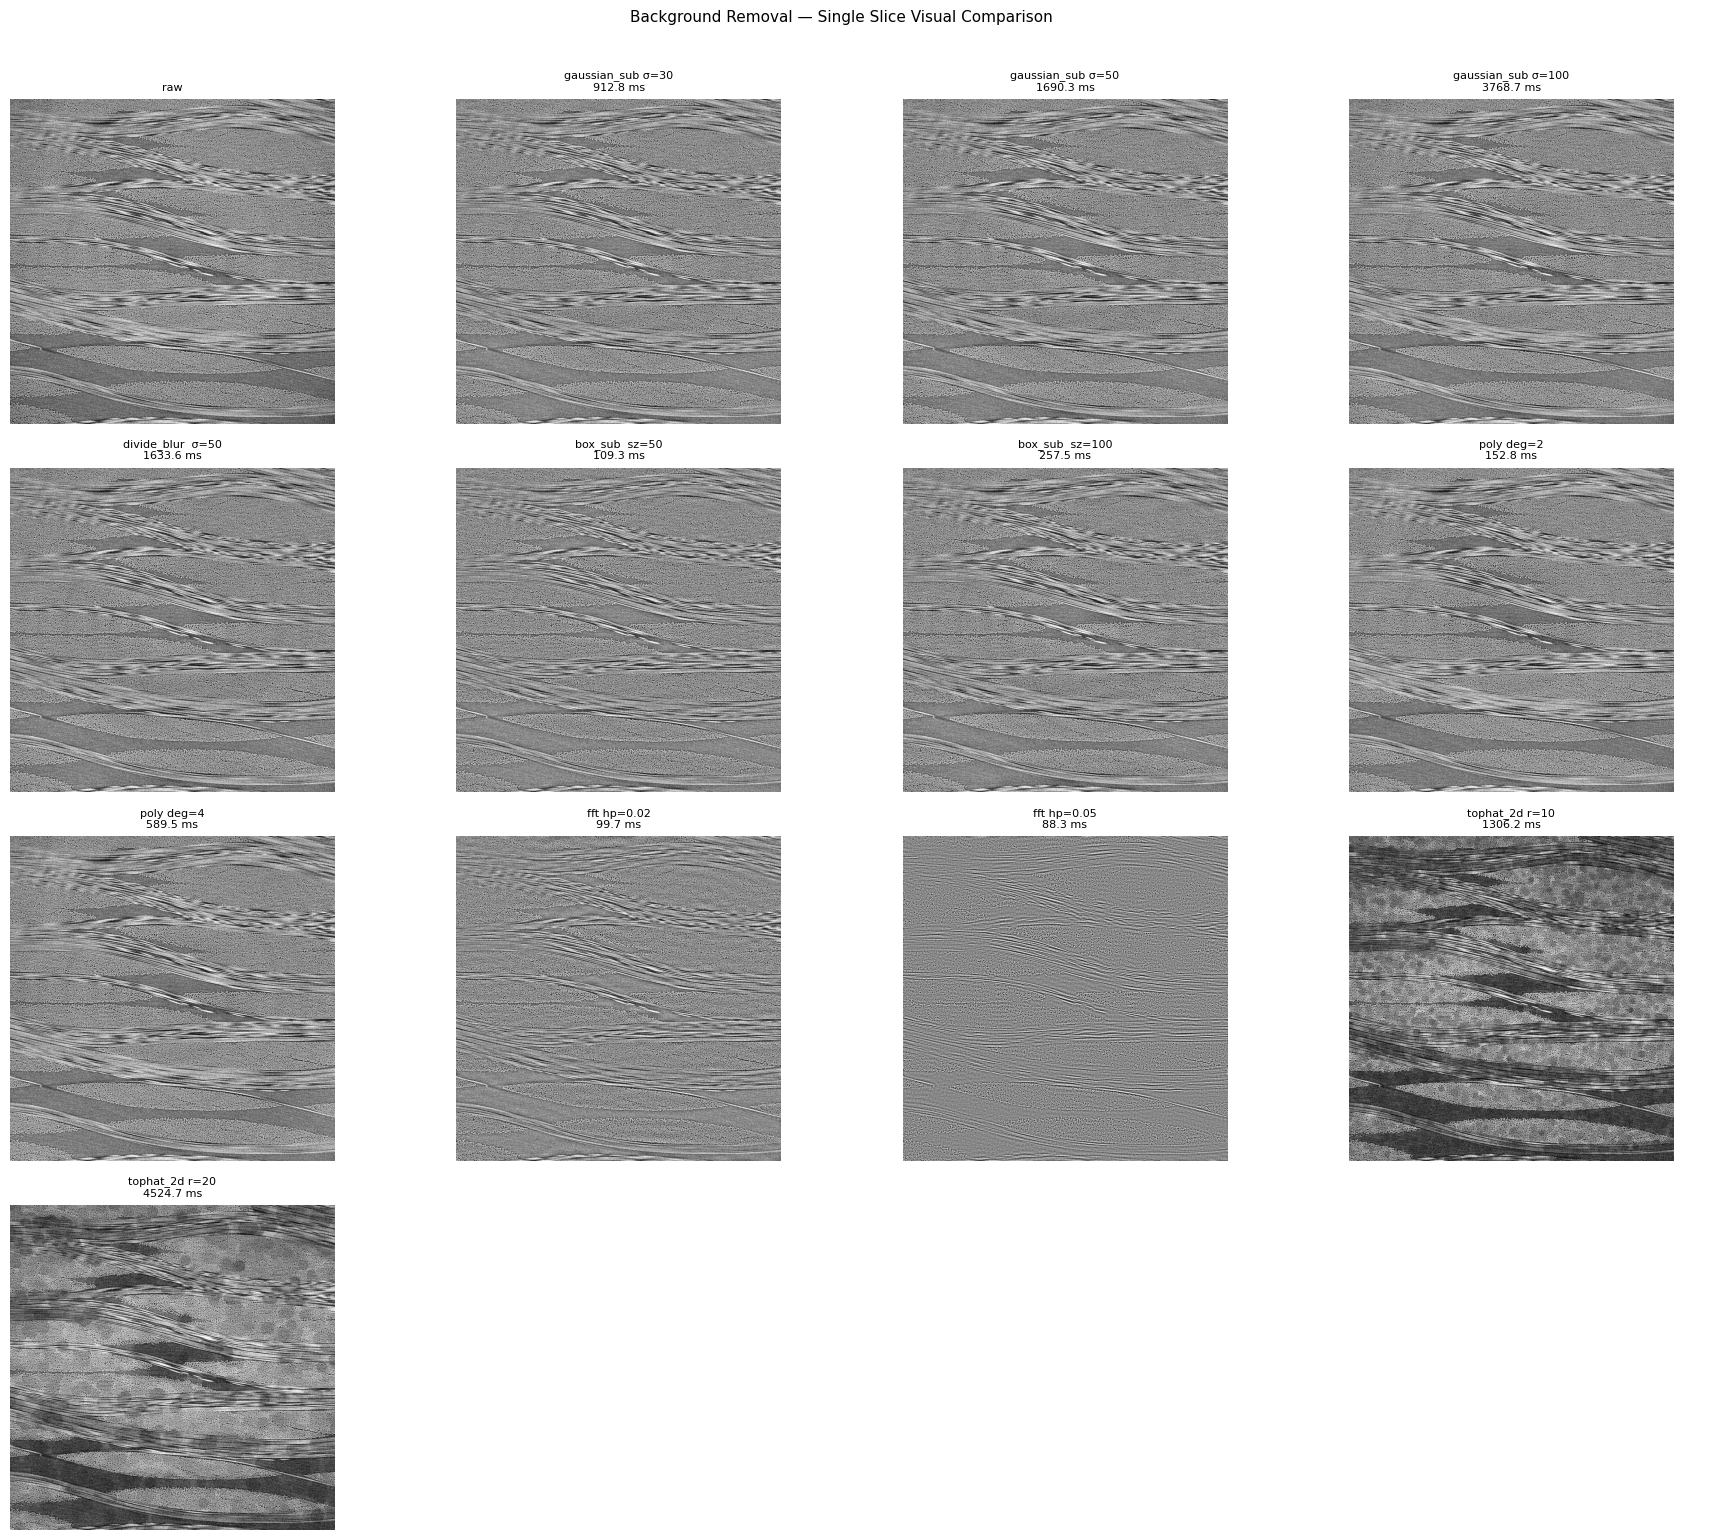

In [10]:
n_total = len(results_2d) + 1   # +1 for raw
ncols   = 4
nrows   = (n_total + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.8 * nrows))
ax_iter = iter(axes.flat)

def _show(ax, img, title):
    lo, hi = np.percentile(img, [1, 99])
    ax.imshow(img, cmap="gray", vmin=lo, vmax=hi)
    ax.set_title(title, fontsize=8)
    ax.axis("off")

_show(next(ax_iter), slice2d, "raw")

for name, res in results_2d.items():
    _show(next(ax_iter), res["img"], f"{name}\n{res['time_ms']:.1f} ms")

for ax in ax_iter:
    ax.axis("off")

plt.suptitle("Background Removal — Single Slice Visual Comparison", y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

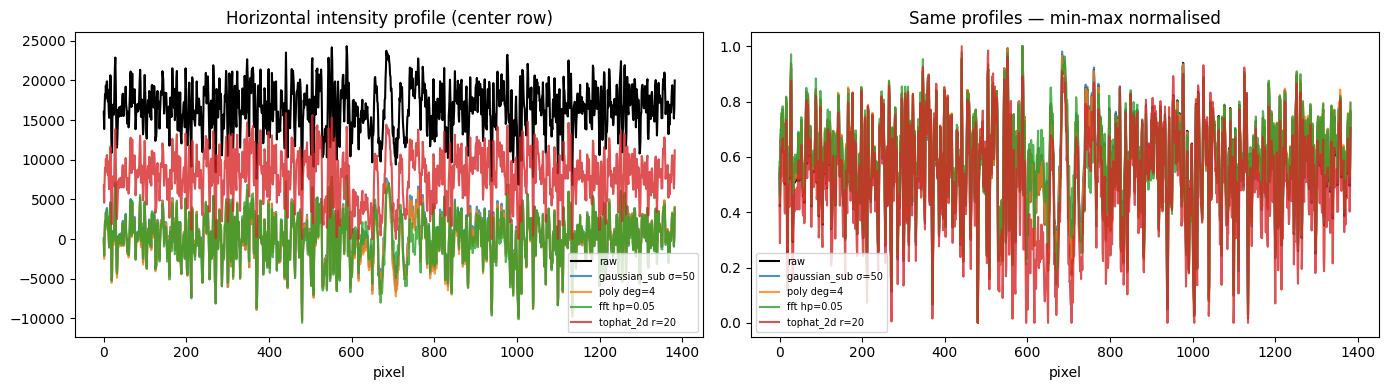

In [11]:
# Horizontal center-row profile for a selection of methods
PROFILE_METHODS = [
    "gaussian_sub σ=50",
    "poly deg=4",
    "fft hp=0.05",
    "tophat_2d r=20",
]
mid_row = slice2d.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Absolute profiles
axes[0].plot(slice2d[mid_row], label="raw", linewidth=1.5, color="black")
for name in PROFILE_METHODS:
    axes[0].plot(results_2d[name]["img"][mid_row], label=name, alpha=0.8)
axes[0].set_title("Horizontal intensity profile (center row)")
axes[0].set_xlabel("pixel")
axes[0].legend(fontsize=7)

# Normalised to [0,1] for shape comparison
def _norm01(a):
    lo, hi = a.min(), a.max()
    return (a - lo) / (hi - lo + 1e-12)

axes[1].plot(_norm01(slice2d[mid_row]), label="raw", linewidth=1.5, color="black")
for name in PROFILE_METHODS:
    axes[1].plot(_norm01(results_2d[name]["img"][mid_row]), label=name, alpha=0.8)
axes[1].set_title("Same profiles — min-max normalised")
axes[1].set_xlabel("pixel")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 5  Quality metrics on the 2-D slice

In [12]:
def corner_std(img: np.ndarray, frac: float = 0.08) -> float:
    """Std in the four corners — proxy for background uniformity (lower = flatter BG)."""
    H, W = img.shape
    ch, cw = max(4, int(H * frac)), max(4, int(W * frac))
    patches = [
        img[:ch, :cw].ravel(),
        img[:ch, -cw:].ravel(),
        img[-ch:, :cw].ravel(),
        img[-ch:, -cw:].ravel(),
    ]
    return float(np.std(np.concatenate(patches)))


def gradient_sharpness(img: np.ndarray) -> float:
    """Mean gradient magnitude — edge preservation (higher = sharper)."""
    gy, gx = np.gradient(img.astype(np.float64))
    return float(np.mean(np.sqrt(gx**2 + gy**2)))


def contrast_pct(img: np.ndarray, lo: float = 1.0, hi: float = 99.0) -> float:
    """Percentile-based dynamic range."""
    return float(np.percentile(img, hi) - np.percentile(img, lo))


def snr_proxy(img: np.ndarray, signal_pct: float = 95.0, noise_frac: float = 0.08) -> float:
    """P95 / corner_std — higher means fibers stand out more against background."""
    cs = corner_std(img, frac=noise_frac)
    if cs < 1e-12:
        return np.inf
    return float(np.percentile(img, signal_pct)) / cs

In [13]:
print(f"{'Method':<26} {'corner_std':>12} {'sharpness':>12} {'contrast':>12} {'snr_proxy':>12} {'time_ms':>10}")
print("-" * 88)

raw_cs   = corner_std(slice2d)
raw_sh   = gradient_sharpness(slice2d)
raw_ct   = contrast_pct(slice2d)
raw_snr  = snr_proxy(slice2d)
print(f"{'raw':<26} {raw_cs:>12.2f} {raw_sh:>12.4f} {raw_ct:>12.1f} {raw_snr:>12.2f} {'—':>10}")

metric_rows = []
for name, res in results_2d.items():
    img = res["img"]
    cs  = corner_std(img)
    sh  = gradient_sharpness(img)
    ct  = contrast_pct(img)
    snr = snr_proxy(img)
    dt  = res["time_ms"]
    metric_rows.append((name, cs, sh, ct, snr, dt))
    print(f"{name:<26} {cs:>12.2f} {sh:>12.4f} {ct:>12.1f} {snr:>12.2f} {dt:>10.1f}")

Method                       corner_std    sharpness     contrast    snr_proxy    time_ms
----------------------------------------------------------------------------------------
raw                             2225.34    1884.3202      12565.0         9.20          —
gaussian_sub σ=30               2167.93    1884.2850      12556.7         1.89      912.8
gaussian_sub σ=50               2197.57    1884.3166      12587.2         1.87     1690.3
gaussian_sub σ=100              2214.89    1884.3230      12577.8         1.87     3768.7
divide_blur  σ=50                  0.14       0.1158          0.8         8.84     1633.6
box_sub  sz=50                  2147.06    1884.5173      12531.2         1.89      109.3
box_sub  sz=100                 2177.88    1884.3130      12592.8         1.89      257.5
poly deg=2                      2206.70    1884.3255      12552.3         1.88      152.8
poly deg=4                      2231.16    1884.3236      12563.0         1.86      589.5
fft hp=0.02

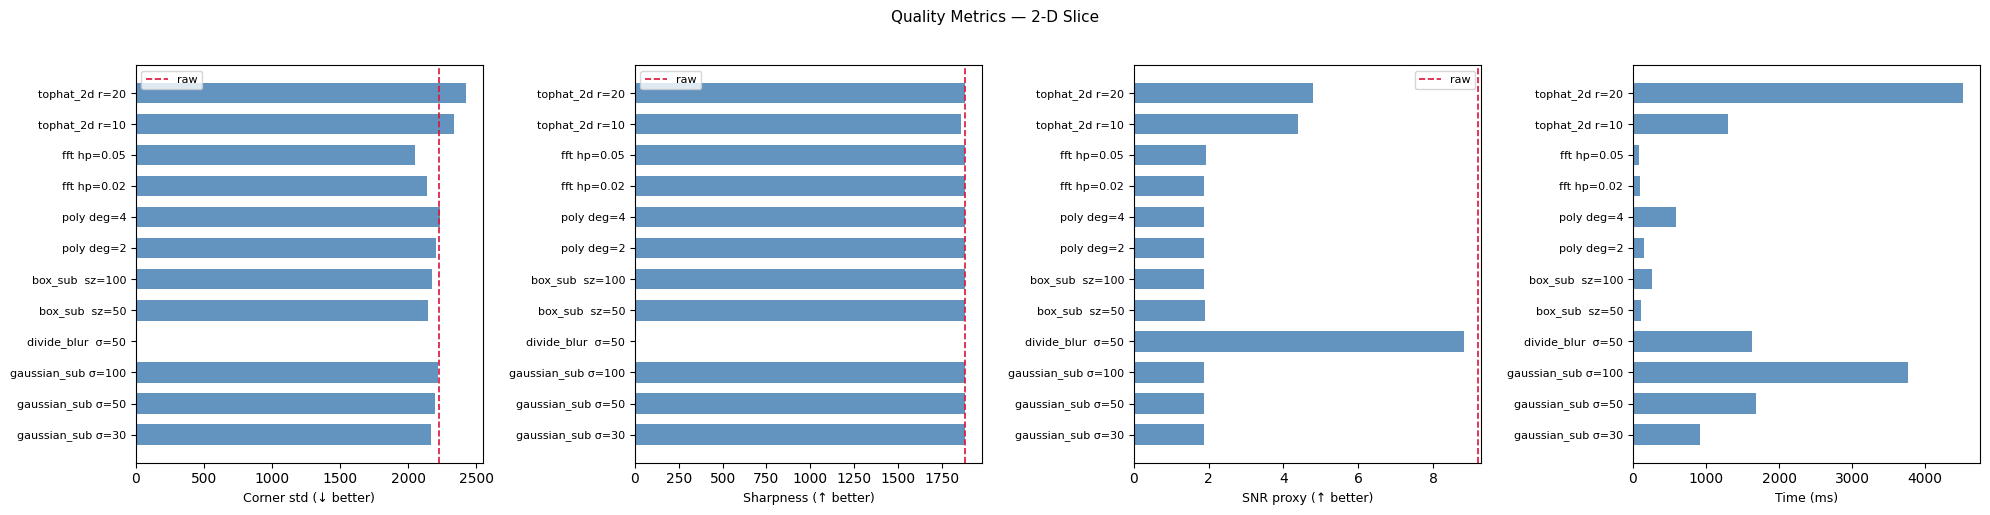

In [14]:
names   = [r[0] for r in metric_rows]
cs_vals = [r[1] for r in metric_rows]
sh_vals = [r[2] for r in metric_rows]
snr_vals = [r[4] for r in metric_rows]
t_vals  = [r[5] for r in metric_rows]

x = np.arange(len(names))
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, vals, ref, label, low_good in zip(
    axes,
    [cs_vals, sh_vals, snr_vals, t_vals],
    [raw_cs, raw_sh, raw_snr, None],
    ["Corner std (↓ better)", "Sharpness (↑ better)", "SNR proxy (↑ better)", "Time (ms)"],
    [True, False, False, None],
):
    bars = ax.barh(x, vals, 0.65, color="steelblue", alpha=0.85)
    if ref is not None:
        ax.axvline(ref, color="crimson", linestyle="--", linewidth=1.2, label="raw")
        ax.legend(fontsize=8)
    ax.set_yticks(x)
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel(label, fontsize=9)

plt.suptitle("Quality Metrics — 2-D Slice", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 6  3-D benchmark — timing on the full slab

In [15]:
METHODS_3D: Dict[str, Callable] = {
    "gaussian_sub σ=30":    lambda v: gaussian_sub(v, sigma=30),
    "gaussian_sub σ=50":    lambda v: gaussian_sub(v, sigma=50),
    "gaussian_sub σ=100":   lambda v: gaussian_sub(v, sigma=100),
    "divide_blur  σ=50":    lambda v: divide_by_blur(v, sigma=50),
    "box_sub  sz=50":        lambda v: box_sub(v, size=50),
    "poly deg=3":            lambda v: poly_bg_per_slice(v, deg=3),
    "fft hp=0.03":           lambda v: fft_highpass(v, cutoff_fraction=0.03),
    "tophat_2d r=10":        lambda v: tophat_2d_per_slice(v, radius=10),
    "tophat_2d r=20":        lambda v: tophat_2d_per_slice(v, radius=20),
}

results_3d: Dict[str, np.ndarray] = {}
timing_3d:  Dict[str, float]      = {}

print(f"Slab shape: {slab_raw.shape}\n")
print(f"{'Method':<26}  {'time (s)':>10}")
print("-" * 40)

for name, fn in METHODS_3D.items():
    t0 = time.perf_counter()
    out = fn(slab_raw)
    dt = time.perf_counter() - t0
    results_3d[name] = out
    timing_3d[name]  = dt
    print(f"{name:<26}  {dt:>10.2f}")

Slab shape: (256, 1383, 1383)

Method                        time (s)
----------------------------------------


KeyboardInterrupt: 

In [ ]:
zi_mid = SLAB_N // 2

print(f"{'Method':<26} {'corner_std':>12} {'sharpness':>12} {'snr_proxy':>12} {'time_s':>10}")
print("-" * 74)
print(f"{'raw':<26} {corner_std(slice2d):>12.2f} {gradient_sharpness(slice2d):>12.4f} {snr_proxy(slice2d):>12.2f} {'—':>10}")

rows_3d = []
for name, vol in results_3d.items():
    mid = vol[zi_mid]
    cs  = corner_std(mid)
    sh  = gradient_sharpness(mid)
    snr = snr_proxy(mid)
    dt  = timing_3d[name]
    rows_3d.append((name, cs, sh, snr, dt))
    print(f"{name:<26} {cs:>12.2f} {sh:>12.4f} {snr:>12.2f} {dt:>10.2f}")

In [ ]:
names3  = [r[0] for r in rows_3d]
cs3     = [r[1] for r in rows_3d]
sh3     = [r[2] for r in rows_3d]
snr3    = [r[3] for r in rows_3d]
t3      = [r[4] for r in rows_3d]
x3      = np.arange(len(names3))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, vals, ref, label in zip(
    axes,
    [cs3, sh3, snr3, t3],
    [raw_cs, raw_sh, raw_snr, None],
    ["Corner std (↓ better)", "Sharpness (↑ better)", "SNR proxy (↑ better)", "Runtime (s)"],
):
    ax.barh(x3, vals, 0.65, color="teal", alpha=0.85)
    if ref is not None:
        ax.axvline(ref, color="crimson", linestyle="--", linewidth=1.2, label="raw")
        ax.legend(fontsize=8)
    ax.set_yticks(x3)
    ax.set_yticklabels(names3, fontsize=8)
    ax.set_xlabel(label, fontsize=9)

plt.suptitle(f"3-D Benchmark — {SLAB_N} slices  {slab_raw.shape}", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 7  Inspect the best method

In [ ]:
# ── adjust to whichever method won above ──────────────────────────────────────
BEST = "gaussian_sub σ=50"

corrected   = results_3d[BEST]
corr_norm   = normalize(corrected,  method="robust")
raw_norm    = normalize(slab_raw,   method="robust")

zi = SLAB_N // 2
diff = raw_norm[zi] - corr_norm[zi]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0, 0].imshow(raw_norm[zi], cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Raw (normalised)")
axes[0, 0].axis("off")

axes[0, 1].imshow(corr_norm[zi], cmap="gray", vmin=0, vmax=1)
axes[0, 1].set_title(f"{BEST} (normalised)")
axes[0, 1].axis("off")

im = axes[0, 2].imshow(diff, cmap="bwr", vmin=-0.15, vmax=0.15)
axes[0, 2].set_title("Difference (raw − corrected)")
axes[0, 2].axis("off")
plt.colorbar(im, ax=axes[0, 2], fraction=0.046)

mid_r = raw_norm.shape[1] // 2
mid_c = raw_norm.shape[2] // 2

axes[1, 0].plot(raw_norm[zi, mid_r, :],  label="raw",   color="black", lw=1.5)
axes[1, 0].plot(corr_norm[zi, mid_r, :], label=BEST, alpha=0.85)
axes[1, 0].set_title("Horizontal profile (centre row)")
axes[1, 0].set_xlabel("pixel")
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(raw_norm[zi, :, mid_c],  label="raw",   color="black", lw=1.5)
axes[1, 1].plot(corr_norm[zi, :, mid_c], label=BEST, alpha=0.85)
axes[1, 1].set_title("Vertical profile (centre col)")
axes[1, 1].set_xlabel("pixel")
axes[1, 1].legend(fontsize=8)

axes[1, 2].imshow(corr_norm.mean(axis=0), cmap="gray")
axes[1, 2].set_title("Mean Z-projection (corrected)")
axes[1, 2].axis("off")

plt.suptitle(f"Best method: {BEST}", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 8  Effect on structure tensor

Run ST on raw vs corrected on a thin sub-slab and compare orientation fields.

In [ ]:
from structure_tensor import structure_tensor_3d, eig_special_3d
from structure_tensor.metrics import cosine_similarity
from structure_tensor.post_processing import align_direction

sigma_st = round(np.sqrt(FIBER_R_PX**2 / 2), 2)
rho_st   = 4 * sigma_st
print(f"ST σ={sigma_st:.3f}  ρ={rho_st:.3f}")

# Use a thin slice to keep it fast
N_ST = min(8, SLAB_N)
raw_sub  = normalize(slab_raw[:N_ST],      method="robust")
corr_sub = normalize(corrected[:N_ST],     method="robust")

S_raw  = structure_tensor_3d(raw_sub,  sigma_st, rho_st)
S_corr = structure_tensor_3d(corr_sub, sigma_st, rho_st)

_, vec_raw  = eig_special_3d(S_raw,  full=False)
_, vec_corr = eig_special_3d(S_corr, full=False)

axes_align = ("y", "z")
vec_raw  = align_direction(vec_raw,  axes=axes_align)
vec_corr = align_direction(vec_corr, axes=axes_align)

mean_cos, min_cos, max_ang = cosine_similarity(vec_raw, vec_corr)
print(f"Cosine similarity  raw vs corrected: mean={mean_cos:.4f}  max_angle={max_ang:.2f}°")

In [ ]:
zi_st = N_ST // 2
step  = 20

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, img, vec, title in zip(
    axes,
    [raw_sub[zi_st], corr_sub[zi_st]],
    [vec_raw, vec_corr],
    ["Raw", f"Corrected ({BEST})"],
):
    H, W = img.shape
    Y, X = np.mgrid[0:H:step, 0:W:step]
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.quiver(
        X, Y,
        vec[0, zi_st, ::step, ::step],
        vec[1, zi_st, ::step, ::step],
        color="cyan", angles="xy", scale_units="xy", scale=None, width=0.003,
    )
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.suptitle(f"Orientation field — raw vs corrected  (mean cosine similarity: {mean_cos:.4f})",
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

## 9  Recommendation

| Priority | Method | Why |
|---|---|---|
| **1st** | `gaussian_sub σ=50–100` | Fast, separable, handles smooth cupping well; σ controls the spatial scale of what's removed |
| **2nd** | `poly deg=3–4 per slice` | Best for strong beam-hardening (bowl-shaped per slice); slower but slice-independent |
| **3rd** | `fft hp=0.02–0.05` | Cleanest spectral separation; can introduce ringing near sharp edges |
| **4th** | `tophat_2d r=20` | Best morphological option; preserves bright compact objects; slower for large SE |

**Suggested pipeline before structure-tensor:**
```python
from scipy.ndimage import gaussian_filter

sigma_bg = 60          # px — tune per dataset
vol_corrected = vol - gaussian_filter(vol, sigma=sigma_bg)
vol_norm      = normalize(vol_corrected, method='robust')
```

> **Rule of thumb for σ_bg**: set it to at least `5 × fiber_diameter_px`.
> For this dataset that is `5 × 3 ≈ 15 px` minimum, but `50–100 px` is safer to avoid
> attenuating the fiber signal.

In [ ]:
# ── Optional: apply to the whole volume and save ──────────────────────────────
# Uncomment and set out_path to run

# SIGMA_BG = 60
# out_path = FILE_PATH.parent / (FILE_PATH.stem + "_bg_corrected.h5")
#
# from structure_tensor.h5_io import H5BlockReader, H5BlockWriter
#
# with h5py.File(FILE_PATH, "r") as f:
#     ds    = f[vol_key]
#     shape = ds.shape
#     dtype = np.float32
#
# specs = {
#     vol_key: dict(
#         shape=shape, dtype=dtype,
#         chunks=(32, 256, 256), compression="gzip", compression_opts=4,
#     )
# }
#
# with H5BlockReader(FILE_PATH, (vol_key,), block_size=(64, 256, 256)) as reader, \
#      H5BlockWriter(out_path, specs) as writer:
#     for (zsl, ysl, xsl), batch in reader:
#         blk = batch[vol_key].astype(np.float32)
#         blk_corr = blk - gaussian_filter(blk, sigma=SIGMA_BG)
#         writer.write_block(vol_key, zsl, ysl, xsl, blk_corr.astype(np.float32))
#
# print("Saved to:", out_path)